## Step 0 : Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import date

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 1 : Load Dataset from Yahoo Finance (Web Scraping)

We use the `yfinance` library to download historical OHLCV (Open, High, Low, Close, Volume) data directly from Yahoo Finance.

In [ ]:

TICKER = "AAPL"                      
START_DATE = "2015-01-01"             
END_DATE = date.today().strftime("%Y-%m-%d")  

print(f"Ticker     : {TICKER}")
print(f"Date range : {START_DATE}  ->  {END_DATE}")

data = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data.reset_index(inplace=True)

print(f"Rows loaded: {len(data)}")
print(f"Columns    : {list(data.columns)}")
data.head()

Ticker     : AAPL
Date range : 2015-01-01  ->  2026-04-29
YF.download() has changed argument auto_adjust default to True
Rows loaded: 2846
Columns    : ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


Price,Date,Close,High,Low,Open,Volume
0,2015-01-02,24.214897,24.682230,23.776357,24.671155,212818400
1,2015-01-05,23.532724,24.064287,23.346678,23.984553,257142000
2,2015-01-06,23.534943,23.794079,23.173922,23.596958,263188400
3,2015-01-07,23.864948,23.964616,23.632389,23.743131,160423600
4,2015-01-08,24.781891,24.839477,24.075355,24.192743,237458000


## Step 2 : Feature Engineering - Technical Indicators

We extract **18 technical indicators** from the raw OHLCV data to use as features:

| # | Feature | Description |
|---|---------|-------------|
| 1-2 | SMA (7, 21) | Simple Moving Averages |
| 3-4 | EMA (7, 21) | Exponential Moving Averages |
| 5 | RSI (14) | Relative Strength Index |
| 6-7 | MACD, Signal | Moving Average Convergence Divergence |
| 8-10 | Bollinger Bands | Upper, Middle, Lower bands |
| 11-14 | Returns & Volume | Daily return, volume change, high-low range, open-close diff |
| 15-18 | Lag Features | Lagged returns (1, 2, 3, 5 days) |

In [ ]:
df = data.copy()

df["SMA_7"]  = df["Close"].rolling(window=7).mean()
df["SMA_21"] = df["Close"].rolling(window=21).mean()

df["EMA_7"]  = df["Close"].ewm(span=7, adjust=False).mean()
df["EMA_21"] = df["Close"].ewm(span=21, adjust=False).mean()


def compute_rsi(series, period=14):
    """Compute RSI (Relative Strength Index) for a price series."""
    delta = series.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df["RSI"] = compute_rsi(df["Close"], period=14)


ema_12 = df["Close"].ewm(span=12, adjust=False).mean()
ema_26 = df["Close"].ewm(span=26, adjust=False).mean()
df["MACD"]        = ema_12 - ema_26
df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

bb_window = 20
df["BB_Middle"] = df["Close"].rolling(window=bb_window).mean()
bb_std          = df["Close"].rolling(window=bb_window).std()
df["BB_Upper"]  = df["BB_Middle"] + 2 * bb_std
df["BB_Lower"]  = df["BB_Middle"] - 2 * bb_std


df["Daily_Return"]   = df["Close"].pct_change()          
df["Volume_Change"]  = df["Volume"].pct_change()          
df["High_Low_Range"] = (df["High"] - df["Low"]) / df["Close"]  
df["Open_Close_Diff"]= (df["Close"] - df["Open"]) / df["Open"] 
for lag in [1, 2, 3, 5]:
    df[f"Return_Lag_{lag}"] = df["Daily_Return"].shift(lag)

print("Technical indicators computed successfully!")
df.head()

Technical indicators computed successfully!


Price,Date,Close,High,Low,Open,Volume,SMA_7,SMA_21,EMA_7,EMA_21,...,BB_Upper,BB_Lower,Daily_Return,Volume_Change,High_Low_Range,Open_Close_Diff,Return_Lag_1,Return_Lag_2,Return_Lag_3,Return_Lag_5
0,2015-01-02,24.214897,24.682230,23.776357,24.671155,212818400,NaN,NaN,24.214897,24.214897,...,NaN,NaN,NaN,NaN,0.037410,-0.018494,NaN,NaN,NaN,NaN
1,2015-01-05,23.532724,24.064287,23.346678,23.984553,257142000,NaN,NaN,24.044354,24.152881,...,NaN,NaN,-0.028172,0.208270,0.030494,-0.018838,NaN,NaN,NaN,NaN
2,2015-01-06,23.534943,23.794079,23.173922,23.596958,263188400,NaN,NaN,23.917001,24.096705,...,NaN,NaN,0.000094,0.023514,0.026350,-0.002628,-0.028172,NaN,NaN,NaN
3,2015-01-07,23.864948,23.964616,23.632389,23.743131,160423600,NaN,NaN,23.903988,24.075636,...,NaN,NaN,0.014022,-0.390461,0.013921,0.005131,0.000094,-0.028172,NaN,NaN
4,2015-01-08,24.781891,24.839477,24.075355,24.192743,237458000,NaN,NaN,24.123464,24.139841,...,NaN,NaN,0.038422,0.480194,0.030834,0.024352,0.014022,0.000094,-0.028172,NaN


## Step 3 : Create Target Variable (Label)

We define a **binary classification** target:
- `1` (UP) : if next day's Close > today's Close
- `0` (DOWN) : otherwise

In [ ]:
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

print("Target = 1 if next-day Close > today's Close, else 0")
print(f"\nClass distribution:\n{df['Target'].value_counts()}")

Target = 1 if next-day Close > today's Close, else 0

Class distribution:
Target
1    1510
0    1336
Name: count, dtype: int64


## Step 4 : Prepare Feature Matrix (X) and Labels (y)

In [ ]:
feature_cols = [
    "SMA_7", "SMA_21", "EMA_7", "EMA_21",
    "RSI", "MACD", "MACD_Signal",
    "BB_Upper", "BB_Middle", "BB_Lower",
    "Daily_Return", "Volume_Change",
    "High_Low_Range", "Open_Close_Diff",
    "Return_Lag_1", "Return_Lag_2", "Return_Lag_3", "Return_Lag_5",
]

df.dropna(inplace=True)

X = df[feature_cols].values 
y = df["Target"].values       

print(f"Feature columns ({len(feature_cols)}): {feature_cols}")
print(f"Dataset shape  : X = {X.shape}, y = {y.shape}")
print(f"Class balance  : UP = {np.sum(y == 1)}, DOWN = {np.sum(y == 0)}")

Feature columns (18): ['SMA_7', 'SMA_21', 'EMA_7', 'EMA_21', 'RSI', 'MACD', 'MACD_Signal', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'Daily_Return', 'Volume_Change', 'High_Low_Range', 'Open_Close_Diff', 'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3', 'Return_Lag_5']
Dataset shape  : X = (2826, 18), y = (2826,)
Class balance  : UP = 1497, DOWN = 1329


## Step 5 : Split into Train, Validation, and Test Sets

We use a **60/20/20** split with `shuffle=False` to respect chronological order (important for time-series data).

In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=False  
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, shuffle=False
)

print(f"Training set   : {X_train.shape[0]} samples")
print(f"Validation set : {X_val.shape[0]} samples")
print(f"Test set       : {X_test.shape[0]} samples")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("\nFeatures standardised (zero mean, unit variance).")

Training set   : 1695 samples
Validation set : 565 samples
Test set       : 566 samples

Features standardised (zero mean, unit variance).


## Step 6 : Train Classical ML Models

We train **4 classical ML models**:

| Model | Key Hyperparameters |
|-------|-------------------|
| **SVM** | RBF kernel, C=1.0, gamma=scale |
| **Random Forest** | 200 trees, max_depth=10 |
| **KNN** | k=5 neighbours |
| **Logistic Regression** | max_iter=1000 |

In [ ]:
models = {
    "Support Vector Machine (SVM)": SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42),
    "Random Forest":                RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    "K-Nearest Neighbours (KNN)":   KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression":          LogisticRegression(max_iter=1000, random_state=42),
}

results = {}

for name, model in models.items():
    print(f"\n>> Training {name} ...")

    if name == "Random Forest":
        model.fit(X_train, y_train)
        y_val_pred  = model.predict(X_val)
        y_test_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_val_pred  = model.predict(X_val_scaled)
        y_test_pred = model.predict(X_test_scaled)

    val_acc  = accuracy_score(y_val, y_val_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    results[name] = {
        "model":       model,
        "val_acc":      val_acc,
        "test_acc":     test_acc,
        "y_test_pred":  y_test_pred,
    }

    print(f"   Validation Accuracy : {val_acc:.4f}")
    print(f"   Test Accuracy       : {test_acc:.4f}")


>> Training Support Vector Machine (SVM) ...
   Validation Accuracy : 0.5062
   Test Accuracy       : 0.5212

>> Training Random Forest ...
   Validation Accuracy : 0.4938
   Test Accuracy       : 0.4770

>> Training K-Nearest Neighbours (KNN) ...
   Validation Accuracy : 0.4903
   Test Accuracy       : 0.5018

>> Training Logistic Regression ...
   Validation Accuracy : 0.5027
   Test Accuracy       : 0.4982


## Step 7 : Evaluation - Accuracy, Confusion Matrix, Classification Report

In [8]:
class_names = ["DOWN (0)", "UP (1)"]

for name, res in results.items():
    print(f"\n{'-' * 60}")
    print(f"  MODEL : {name}")
    print(f"{'-' * 60}")
    print(f"  Test Accuracy: {res['test_acc']:.4f}\n")

    print("  Classification Report:")
    report = classification_report(y_test, res["y_test_pred"], target_names=class_names)
    print(report)

    cm = confusion_matrix(y_test, res["y_test_pred"])
    print(f"  Confusion Matrix:\n  {cm}\n")


------------------------------------------------------------
  MODEL : Support Vector Machine (SVM)
------------------------------------------------------------
  Test Accuracy: 0.5212

  Classification Report:
              precision    recall  f1-score   support

    DOWN (0)       0.37      0.06      0.10       260
      UP (1)       0.53      0.92      0.67       306

    accuracy                           0.52       566
   macro avg       0.45      0.49      0.39       566
weighted avg       0.46      0.52      0.41       566

  Confusion Matrix:
  [[ 15 245]
 [ 26 280]]


------------------------------------------------------------
  MODEL : Random Forest
------------------------------------------------------------
  Test Accuracy: 0.4770

  Classification Report:
              precision    recall  f1-score   support

    DOWN (0)       0.46      0.88      0.61       260
      UP (1)       0.57      0.14      0.22       306

    accuracy                           0.48       566


## Step 8 : Model Comparison

In [9]:
comparison_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Validation Accuracy": [r["val_acc"] for r in results.values()],
    "Test Accuracy":       [r["test_acc"] for r in results.values()],
})
comparison_df = comparison_df.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

best_model_name = comparison_df.iloc[0]["Model"]
best_test_acc   = comparison_df.iloc[0]["Test Accuracy"]
print(f"Best Model: {best_model_name} (Test Accuracy = {best_test_acc:.4f})\n")

comparison_df

Best Model: Support Vector Machine (SVM) (Test Accuracy = 0.5212)



,Model,Validation Accuracy,Test Accuracy
0,Support Vector Machine (SVM),0.506195,0.521201
1,K-Nearest Neighbours (KNN),0.490265,0.501767
2,Logistic Regression,0.502655,0.498233
3,Random Forest,0.493805,0.477032


## Step 9 : Visualisations / Graphs

### 9a. Stock Price with Moving Averages

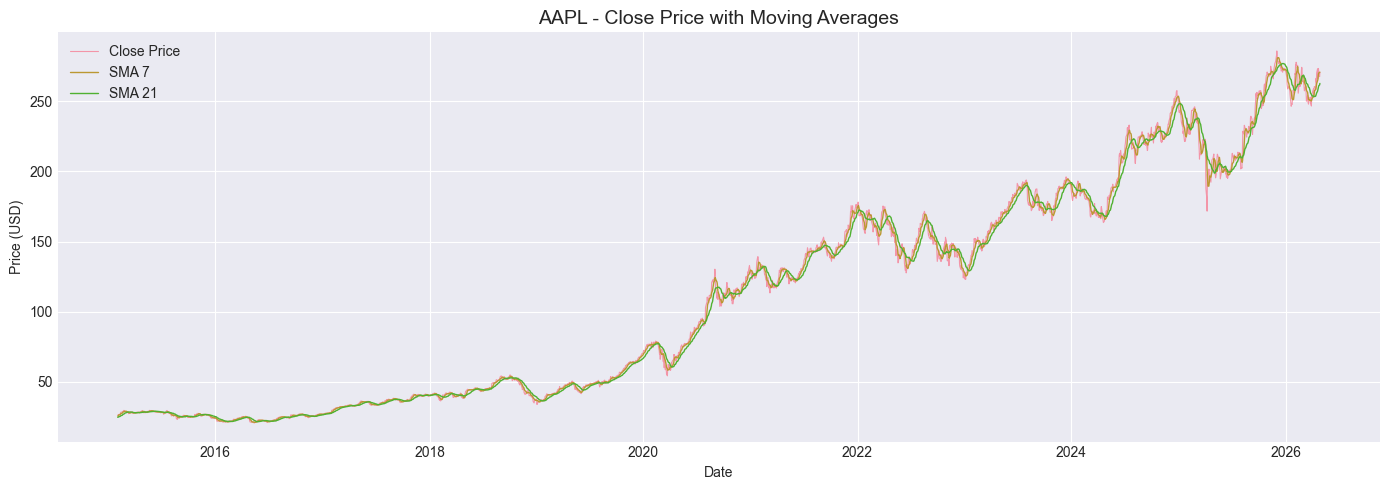

In [10]:
fig1, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(df["Date"], df["Close"], label="Close Price", linewidth=0.8, alpha=0.7)
ax1.plot(df["Date"], df["SMA_7"], label="SMA 7", linewidth=1)
ax1.plot(df["Date"], df["SMA_21"], label="SMA 21", linewidth=1)
ax1.set_title(f"{TICKER} - Close Price with Moving Averages", fontsize=14)
ax1.set_xlabel("Date")
ax1.set_ylabel("Price (USD)")
ax1.legend()
fig1.tight_layout()
fig1.savefig("01_price_and_sma.png", dpi=150)
plt.show()

### 9b. RSI (Relative Strength Index)

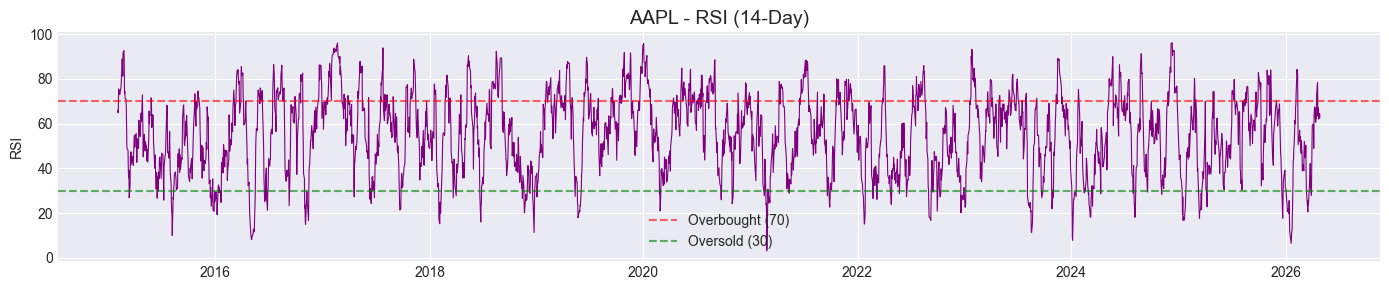

In [11]:
fig2, ax2 = plt.subplots(figsize=(14, 3))
ax2.plot(df["Date"], df["RSI"], color="purple", linewidth=0.8)
ax2.axhline(70, color="red", linestyle="--", alpha=0.6, label="Overbought (70)")
ax2.axhline(30, color="green", linestyle="--", alpha=0.6, label="Oversold (30)")
ax2.set_title(f"{TICKER} - RSI (14-Day)", fontsize=14)
ax2.set_ylabel("RSI")
ax2.legend()
fig2.tight_layout()
fig2.savefig("02_rsi.png", dpi=150)
plt.show()

### 9c. Model Accuracy Comparison

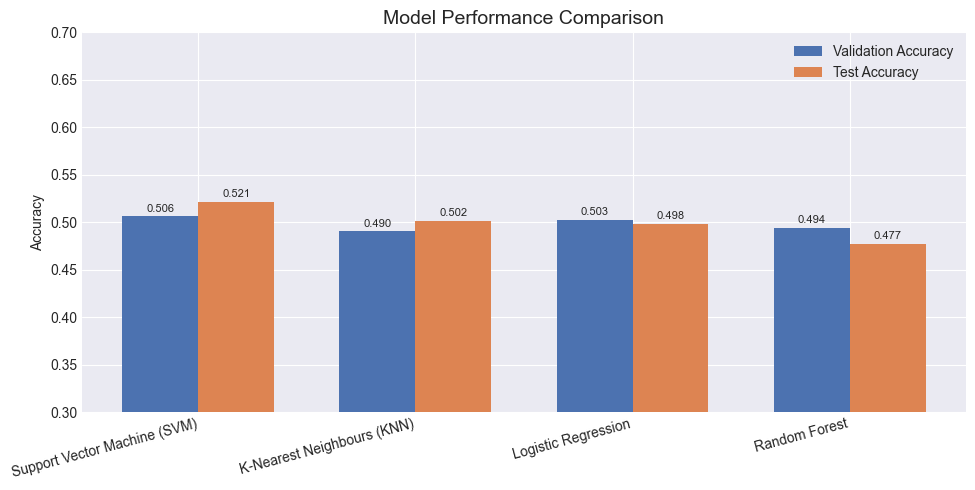

In [12]:
fig3, ax3 = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(comparison_df))
bar_width = 0.35

bars1 = ax3.bar(x_pos - bar_width / 2, comparison_df["Validation Accuracy"],
                bar_width, label="Validation Accuracy", color="#4C72B0")
bars2 = ax3.bar(x_pos + bar_width / 2, comparison_df["Test Accuracy"],
                bar_width, label="Test Accuracy", color="#DD8452")

ax3.set_ylabel("Accuracy")
ax3.set_title("Model Performance Comparison", fontsize=14)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(comparison_df["Model"], rotation=15, ha="right")
ax3.legend()
ax3.set_ylim(0.3, 0.7)
ax3.bar_label(bars1, fmt="%.3f", fontsize=8, padding=2)
ax3.bar_label(bars2, fmt="%.3f", fontsize=8, padding=2)
fig3.tight_layout()
fig3.savefig("03_model_comparison.png", dpi=150)
plt.show()

### 9d. Confusion Matrices

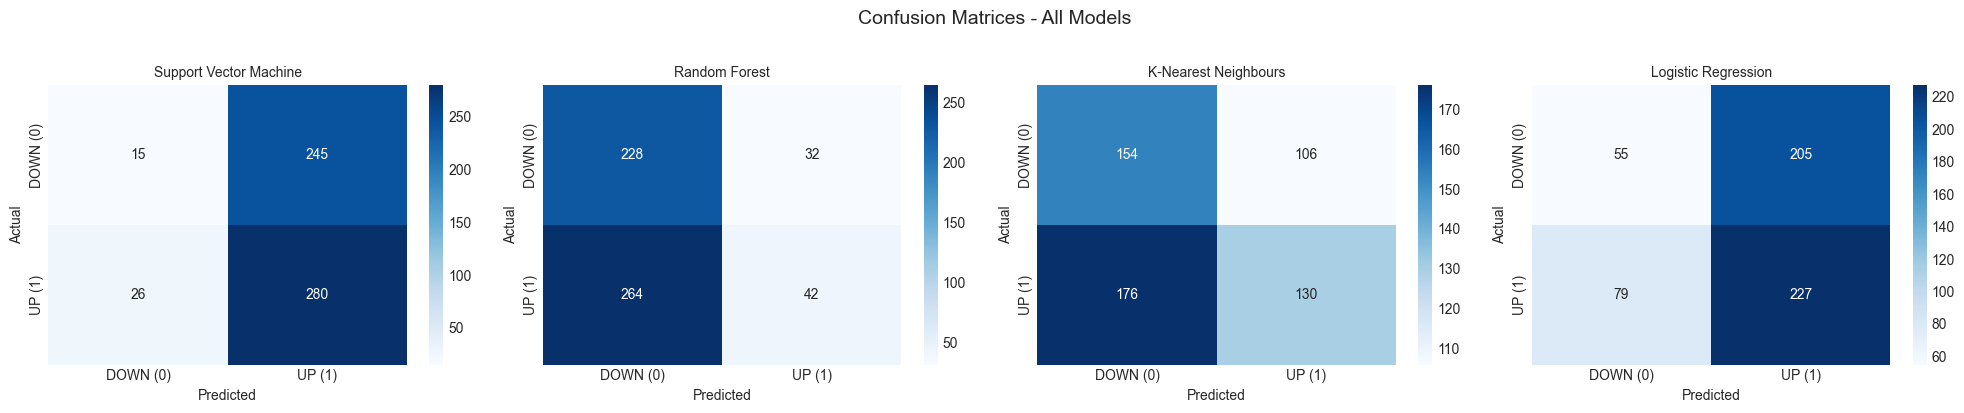

In [13]:
fig4, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_test_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(name.split("(")[0].strip(), fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
fig4.suptitle("Confusion Matrices - All Models", fontsize=14, y=1.02)
fig4.tight_layout()
fig4.savefig("04_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

### 9e. Feature Importance (Random Forest)

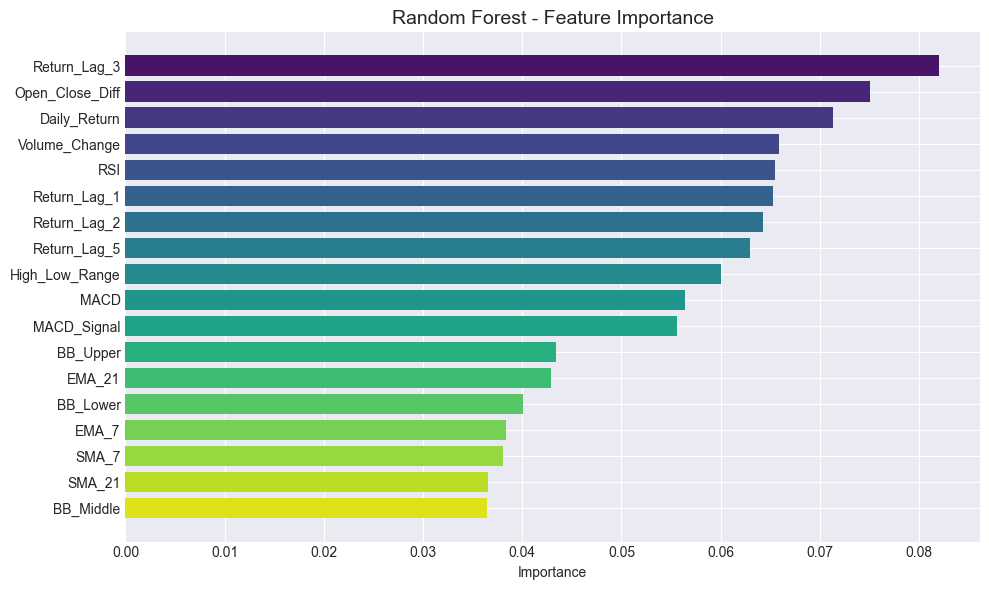

In [14]:
rf_model = results["Random Forest"]["model"]
importances = rf_model.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

fig5, ax5 = plt.subplots(figsize=(10, 6))
ax5.barh(
    [feature_cols[i] for i in sorted_idx],
    importances[sorted_idx],
    color=sns.color_palette("viridis", len(feature_cols)),
)
ax5.set_xlabel("Importance")
ax5.set_title("Random Forest - Feature Importance", fontsize=14)
ax5.invert_yaxis()
fig5.tight_layout()
fig5.savefig("05_feature_importance.png", dpi=150)
plt.show()

## Final Summary

In [16]:
print("=" * 70)
print("  PROJECT COMPLETE - STOCK PREDICTION USING CLASSICAL ML")
print("=" * 70)
print(f"""
  Ticker analysed : {TICKER}
  Data range       : {START_DATE} -> {END_DATE}
  Total samples    : {len(df)}
  Features used    : {len(feature_cols)} technical indicators
  Models trained   : {len(models)}
  Best model       : {best_model_name}
  Best test acc    : {best_test_acc:.4f}
""")

  PROJECT COMPLETE - STOCK PREDICTION USING CLASSICAL ML

  Ticker analysed : AAPL
  Data range       : 2015-01-01 -> 2026-04-29
  Total samples    : 2826
  Features used    : 18 technical indicators
  Models trained   : 4
  Best model       : Support Vector Machine (SVM)
  Best test acc    : 0.5212

